In [7]:
import numpy as np
from PIL import Image
from scipy.ndimage import map_coordinates
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import shutil

## Functions

In [8]:
def map_to_sphere(x, y, z, yaw_radian, pitch_radian):


    theta = np.arccos(z / np.sqrt(x ** 2 + y ** 2 + z ** 2))
    phi = np.arctan2(y, x)

    # Apply rotation transformations here
    theta_prime = np.arccos(np.sin(theta) * np.sin(phi) * np.sin(pitch_radian) +
                            np.cos(theta) * np.cos(pitch_radian))

    phi_prime = np.arctan2(np.sin(theta) * np.sin(phi) * np.cos(pitch_radian) -
                           np.cos(theta) * np.sin(pitch_radian),
                           np.sin(theta) * np.cos(phi))
    phi_prime += yaw_radian
    phi_prime = phi_prime % (2 * np.pi)

    return theta_prime.flatten(), phi_prime.flatten()


def interpolate_color(coords, img, method='bilinear'):
    order = {'nearest': 0, 'bilinear': 1, 'bicubic': 3}.get(method, 1)
    red = map_coordinates(img[:, :, 0], coords, order=order, mode='reflect')
    green = map_coordinates(img[:, :, 1], coords, order=order, mode='reflect')
    blue = map_coordinates(img[:, :, 2], coords, order=order, mode='reflect')
    return np.stack((red, green, blue), axis=-1)


def panorama_to_plane(panorama_path, FOV, output_size, yaw, pitch):
    panorama = Image.open(panorama_path).convert('RGB')
    pano_width, pano_height = panorama.size
    pano_array = np.array(panorama)
    yaw_radian = np.radians(yaw)
    pitch_radian = np.radians(pitch)

    W, H = output_size
    f = (0.5 * W) / np.tan(np.radians(FOV) / 2)

    u, v = np.meshgrid(np.arange(W), np.arange(H), indexing='xy')

    x = u - W / 2
    y = H / 2 - v
    z = f

    theta, phi = map_to_sphere(x, y, z, yaw_radian, pitch_radian)

    U = phi * pano_width / (2 * np.pi)
    V = theta * pano_height / np.pi

    U, V = U.flatten(), V.flatten()
    coords = np.vstack((V, U))

    colors = interpolate_color(coords, pano_array)
    output_image = Image.fromarray(colors.reshape((H, W, 3)).astype('uint8'), 'RGB')

    return output_image


## Run

100%|██████████| 72/72 [00:40<00:00,  1.80it/s]


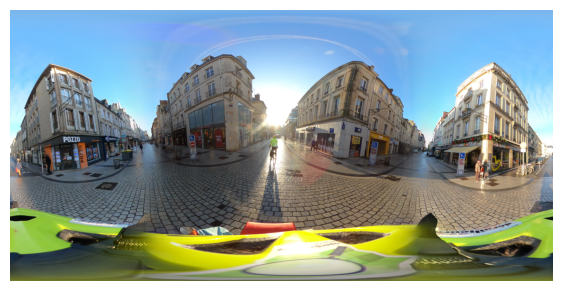

In [10]:
image_id = "cc6b8656-d52e-42d1-ab10-542588c9f9f0"
panorama_path = f"svp/{image_id}.jpg"

output_dir = f"out2_{image_id}"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)    

os.makedirs(output_dir, exist_ok=True) 


panorama = Image.open(panorama_path)
pano_width, pano_height = panorama.size

plt.figure(figsize=(7,4))
plt.axis("off")
plt.imshow(panorama)



for deg in tqdm(np.arange(0, 360, 5)):
    output_image = panorama_to_plane(panorama_path, 80, (600, 600), deg, 90)
    filename = f"img_{image_id}_{int(deg)}.png"
    filepath = os.path.join(output_dir, filename)
    output_image.save(filepath)